In [1]:
# @title Install (Unsloth compatible)

!pip -q uninstall -y datasets
!pip -q install "datasets==4.3.0"
!pip -q install -U "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip -q install -U trl peft accelerate transformers bitsandbytes pandasql Levenshtein


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2025.12.4 requires trl!=0.19.0,<=0.24.0,>=0.18.2, but you have trl 0.26.1 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2025.12.4 requires trl!=0.19.0,<=0.24.0,>=0.18.2, but you have trl 0.26.1 which is incompatible.


In [2]:
# @title Imports & global config


import unsloth
import gc
import sqlite3
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from datasets import load_dataset
from transformers import TrainingArguments, pipeline
from peft import LoraConfig, PeftModel
from trl import SFTTrainer
import pandasql as ps
import Levenshtein as lev

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")


# ----- Config générale -----
# modèle Qwen 7B
MODEL_ID = "Qwen/Qwen2.5-Coder-7B-Instruct"

TRAIN_NUM_SHARDS = 20
TRAIN_SHARD_INDEX = 0
TEST_NUM_SHARDS = 10
TEST_SHARD_INDEX = 0

MAX_EVAL_SAMPLES = 200   # éval plus stable qu’à 20
DO_TRAIN = True          # mets False si tu veux juste tester sans retrain


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [22]:
dataset_name = "gretelai/synthetic_text_to_sql"
dataset = load_dataset(dataset_name)

print(dataset)

train_small = dataset["train"].shard(num_shards=TRAIN_NUM_SHARDS, index=TRAIN_SHARD_INDEX)
test_small  = dataset["test"].shard(num_shards=TEST_NUM_SHARDS,  index=TEST_SHARD_INDEX)

print("Train subset size:", len(train_small))
print("Test subset size:", len(test_small))


def format_prompt_train(examples):
    # Unsloth peut appeler en batch: examples["sql"] est une liste
    # On renvoie UNE liste de prompts de même longueur.

    if isinstance(examples["sql"], list):
        texts = []
        for ctx, q, sql in zip(examples["sql_context"], examples["sql_prompt"], examples["sql"]):
            texts.append(f"""### INSTRUCTION
Given the database schema below, write a SQL query that answers the following question.
The SQL MUST follow the SQLite dialect (SQLite-compatible syntax, functions, and quoting).

### SCHEMA
{ctx}

### QUESTION
{q}

### QUERY
{sql}
""")
        return texts

    # fallback (si jamais appelé en single)
    return [f"""### INSTRUCTION
Given the database schema below, write a SQL query that answers the following question.
The SQL MUST follow the SQLite dialect (SQLite-compatible syntax, functions, and quoting).

### SCHEMA
{examples['sql_context']}

### QUESTION
{examples['sql_prompt']}

### QUERY
{examples['sql']}
"""]


def format_prompt_eval(example):
    # Dialecte SQLite aussi en éval
    return f"""### INSTRUCTION
You are an expert SQL query generator. Output ONLY a valid SQL query. Do not add explanations.
The SQL MUST follow the SQLite dialect (SQLite-compatible syntax).

### SCHEMA
{example['sql_context']}

### QUESTION
{example['sql_prompt']}

### QUERY
""".strip()

def build_eval_prompt(row):
    return format_prompt_eval(row)


DatasetDict({
    train: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
        num_rows: 5851
    })
})
Train subset size: 5000
Test subset size: 586


In [4]:
# @title Normalization & evaluation helpers

def normalize_sql(sql: str) -> str:
    if sql is None:
        return ""
    s = sql.lower()
    s = s.replace("\n", " ").replace("\r", " ")
    s = " ".join(s.split())
    if s.endswith(";"):
        s = s[:-1].strip()
    return s


def levenshtein_ratio(a: str, b: str) -> float:
    a_n, b_n = normalize_sql(a), normalize_sql(b)
    if not a_n and not b_n:
        return 1.0
    return lev.ratio(a_n, b_n)


def build_tables_from_sql_context(sql_context: str) -> dict:
    conn = sqlite3.connect(":memory:")
    try:
        conn.executescript(sql_context)
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
        tables = [r[0] for r in cursor.fetchall()]

        tables_dict = {}
        for t in tables:
            df = pd.read_sql_query(f"SELECT * FROM {t};", conn)
            tables_dict[t] = df
        return tables_dict
    finally:
        conn.close()


def try_execute_with_pandasql(sql_context: str, query: str):
    try:
        tables = build_tables_from_sql_context(sql_context)
        if not tables:
            return False, None
        local_env = tables.copy()
        res = ps.sqldf(query, local_env)
        return True, res
    except Exception:
        return False, None


def normalize_result_df(df: pd.DataFrame | None) -> pd.DataFrame | None:
    if df is None:
        return None
    if df.empty:
        return df.reset_index(drop=True)
    df2 = df.copy()
    df2 = df2.reindex(sorted(df2.columns), axis=1)
    df2 = df2.sort_values(list(df2.columns)).reset_index(drop=True)
    return df2


# --- exec_match bias fix ---
def has_insert(sql_context: str) -> bool:
    if sql_context is None:
        return False
    return bool(re.search(r"\binsert\s+into\b", sql_context, flags=re.IGNORECASE))


def evaluate_example(example, generated_sql: str) -> dict:
    gold_sql = example["sql"]
    ctx = example["sql_context"]

    norm_gold = normalize_sql(gold_sql)
    norm_gen = normalize_sql(generated_sql)

    exact = int(norm_gold == norm_gen)
    lev_ratio_val = levenshtein_ratio(gold_sql, generated_sql)

    gold_ok, gold_df = try_execute_with_pandasql(ctx, gold_sql)
    gen_ok,  gen_df  = try_execute_with_pandasql(ctx, generated_sql)

    eligible = has_insert(ctx)

    exec_match = np.nan
    if eligible and gold_ok and gen_ok and gold_df is not None and gen_df is not None:
        gold_norm_df = normalize_result_df(gold_df)
        gen_norm_df  = normalize_result_df(gen_df)
        exec_match = int(gold_norm_df.equals(gen_norm_df))

    return {
        "norm_exact": exact,
        "lev_ratio": lev_ratio_val,
        "gen_executable": int(gen_ok),
        "gold_executable": int(gold_ok),
        "exec_match": exec_match,
        "exec_match_eligible": int(eligible),
    }


In [5]:
# @title Tokenizer & base model (4-bit, bf16)

# Unsloth optimized loader
from unsloth import FastLanguageModel

max_seq_length = 4096          # A100: 2048 safe. monter si VRAM OK
dtype = torch.bfloat16         # A100 = bf16 natif
load_in_4bit = True            # QLoRA -> batch + speed

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_ID,
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
)

# settings utiles
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.truncation_side = "left"


==((====))==  Unsloth 2025.12.5: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [7]:
# @title LoRA config & training args

# LoRA plus riche + modules complets pour 7B
base_model = FastLanguageModel.get_peft_model(
    base_model,
    r=32,  # A100: 16→32 OK en général
    target_modules=[
        "q_proj","k_proj","v_proj","o_proj",
        "gate_proj","up_proj","down_proj"
    ],
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",  # speed/memo
)

# [MODIF-QWEN-UNSLOTH] hyperparams A100: batch↑ en priorité
training_args = TrainingArguments(
    output_dir="./sql_finetune_results_qwen7b_unsloth",

    per_device_train_batch_size=32,     # A100: tente 8 puis 12/16 si VRAM OK
    gradient_accumulation_steps=1,     # batch effectif
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=25,
    save_strategy="epoch",

    fp16=False,
    bf16=True,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    report_to="none",
)


Unsloth: Already have LoRA adapters! We shall skip this step.


In [8]:
# @title Fine-tuning with SFTTrainer (LoRA)

trainer = SFTTrainer(
    model=base_model,
    processing_class=tokenizer,
    train_dataset=train_small,
    formatting_func=format_prompt_train,
    args=training_args,

    #packing = speedup majeur sur A100
    packing=True,
    max_seq_length=max_seq_length,
)

if DO_TRAIN:
    gc.collect()
    torch.cuda.empty_cache()
    print("=== Start training (Qwen7B + Unsloth) ===")
    trainer.train()

    adapter_save_path = "./sql_finetune_adapter_qwen7b_unsloth"
    trainer.save_model(adapter_save_path)
    print("LoRA adapter saved to", adapter_save_path)
else:
    adapter_save_path = "./sql_finetune_adapter_qwen7b_unsloth"
    print("Training skipped, expecting existing adapter at", adapter_save_path)


The model is already on multiple devices. Skipping the move to device specified in `args`.


=== Start training (Qwen7B + Unsloth) ===


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,000 | Num Epochs = 1 | Total steps = 209
O^O/ \_/ \    Batch size per device = 24 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (24 x 1 x 1) = 24
 "-____-"     Trainable parameters = 80,740,352 of 7,696,356,864 (1.05% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
25,0.708600
50,0.446700
75,0.425700
100,0.422000
125,0.422000
150,0.408900
175,0.407700
200,0.411600


LoRA adapter saved to ./sql_finetune_adapter_qwen7b_unsloth


In [9]:
# @title Reload base & finetuned models + pipelines

del trainer
gc.collect()
torch.cuda.empty_cache()

from unsloth import FastLanguageModel
from peft import PeftModel

# reload base (optimized)
base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_ID,
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
)

# reload ft (base + adapter)
ft_model, _ = FastLanguageModel.from_pretrained(
    model_name     = MODEL_ID,
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
)
ft_model = PeftModel.from_pretrained(ft_model, adapter_save_path)

# inference fast path + KV cache
FastLanguageModel.for_inference(base_model)
FastLanguageModel.for_inference(ft_model)

pipe_base = pipeline(
    "text-generation",
    model=base_model,
    tokenizer=tokenizer,
    do_sample=False,
    max_new_tokens=256,
)

pipe_ft = pipeline(
    "text-generation",
    model=ft_model,
    tokenizer=tokenizer,
    do_sample=False,
    max_new_tokens=256,
)


==((====))==  Unsloth 2025.12.5: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
==((====))==  Unsloth 2025.12.5: Fast Qwen2 patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Device set to use cuda:0
Device set to use cuda:0


In [20]:
# @title Eval function (base or finetuned)

def generate_sql_from_model(pipe, example) -> str:
    prompt = format_prompt_eval(example)
    out = pipe(prompt, max_new_tokens=256, do_sample=False)[0]["generated_text"]

    gen_sql = out[len(prompt):].strip()

    gen_sql = gen_sql.replace("```sql", "").replace("```", "")
    gen_sql = gen_sql.replace("`", "")  # sqlite-friendly
    gen_sql = gen_sql.split("###")[0]
    gen_sql = gen_sql.split("```")[0]
    gen_sql = gen_sql.split("\n")[0]
    gen_sql = gen_sql.strip()

    if ";" not in gen_sql:
        gen_sql += ";"
    else:
        gen_sql = gen_sql.split(";")[0] + ";"

    return gen_sql


def eval_model(pipe, eval_dataset, max_samples: int = 30) -> pd.DataFrame:
    rows = []
    n = min(len(eval_dataset), max_samples)
    for i in tqdm(range(n)):
        ex = eval_dataset[i]
        gen_sql = generate_sql_from_model(pipe, ex)
        metrics = evaluate_example(ex, gen_sql)
        rows.append({
            "index": i,
            "prompt": ex["sql_prompt"],
            "gold_sql": ex["sql"],
            "generated_sql": gen_sql,
            **metrics,
        })
    return pd.DataFrame(rows)


In [ ]:
# @title Parallel eval: batch GPU + CPU metrics

from multiprocessing import Pool, cpu_count

def generate_sql_batch(pipe, examples, batch_size=32, max_new_tokens=256):
    prompts = [format_prompt_eval(ex) for ex in examples]
    outs = pipe(prompts, batch_size=batch_size, max_new_tokens=max_new_tokens, do_sample=False)

    gen_sqls = []
    for prompt, o in zip(prompts, outs):
        out_text = o["generated_text"]
        gen_sql = out_text[len(prompt):].strip()
        gen_sql = "SELECT " + gen_sql.lstrip()  # FIX SELECT

        gen_sql = gen_sql.replace("```sql", "").replace("```", "")
        gen_sql = gen_sql.replace("`", "")
        gen_sql = gen_sql.split("###")[0]
        gen_sql = gen_sql.split("```")[0]
        gen_sql = gen_sql.split("\n")[0]
        gen_sql = gen_sql.strip()
        gen_sql = gen_sql.split(";")[0].strip() + ";"

        gen_sqls.append(gen_sql)
    return gen_sqls

def _eval_one(args):
    ex, gen_sql, i = args
    m = evaluate_example(ex, gen_sql)
    return {"index": i, "prompt": ex["sql_prompt"], "gold_sql": ex["sql"], "generated_sql": gen_sql, **m}

def eval_model_parallel(pipe, eval_dataset, max_samples=200, batch_size=32, n_proc=8):
    n = min(len(eval_dataset), max_samples)
    examples = [eval_dataset[i] for i in range(n)]

    # 1) génération GPU batchée
    gen_sqls = generate_sql_batch(pipe, examples, batch_size=batch_size)

    # 2) métriques CPU parallèles
    items = [(examples[i], gen_sqls[i], i) for i in range(n)]
    procs = min(n_proc, cpu_count())
    with Pool(processes=procs) as pool:
        rows = list(tqdm(pool.imap(_eval_one, items), total=n, desc="CPU metrics"))
    return pd.DataFrame(rows)


In [23]:
results_base_df = eval_model(pipe_base, test_small, max_samples=MAX_EVAL_SAMPLES)
results_ft_df   = eval_model(pipe_ft,   test_small, max_samples=MAX_EVAL_SAMPLES)

print("Base eval df shape:", results_base_df.shape)
print("FT eval df shape:", results_ft_df.shape)


100%|██████████| 200/200 [12:10<00:00,  3.65s/it]

Base eval df shape: (200, 10)
FT eval df shape: (200, 10)


In [24]:
# @title Metrics aggregation & comparison

summary_base = {
    "exact_match_rate": results_base_df["norm_exact"].mean(),
    "mean_lev_ratio": results_base_df["lev_ratio"].mean(),
    "gen_executable_rate": results_base_df["gen_executable"].mean(),
    "exec_match_rate": results_base_df["exec_match"].mean(),  # NaN ignorés
    "exec_match_coverage": results_base_df["exec_match_eligible"].mean(),
}

summary_ft = {
    "exact_match_rate": results_ft_df["norm_exact"].mean(),
    "mean_lev_ratio": results_ft_df["lev_ratio"].mean(),
    "gen_executable_rate": results_ft_df["gen_executable"].mean(),
    "exec_match_rate": results_ft_df["exec_match"].mean(),
    "exec_match_coverage": results_ft_df["exec_match_eligible"].mean(),
}

print("Base summary:", summary_base)
print("Finetuned summary:", summary_ft)


Base summary: {'exact_match_rate': np.float64(0.03), 'mean_lev_ratio': np.float64(0.19342534563271083), 'gen_executable_rate': np.float64(0.3), 'exec_match_rate': np.float64(0.5714285714285714), 'exec_match_coverage': np.float64(0.74)}
Finetuned summary: {'exact_match_rate': np.float64(0.305), 'mean_lev_ratio': np.float64(0.8429916489503613), 'gen_executable_rate': np.float64(0.745), 'exec_match_rate': np.float64(0.44954128440366975), 'exec_match_coverage': np.float64(0.74)}


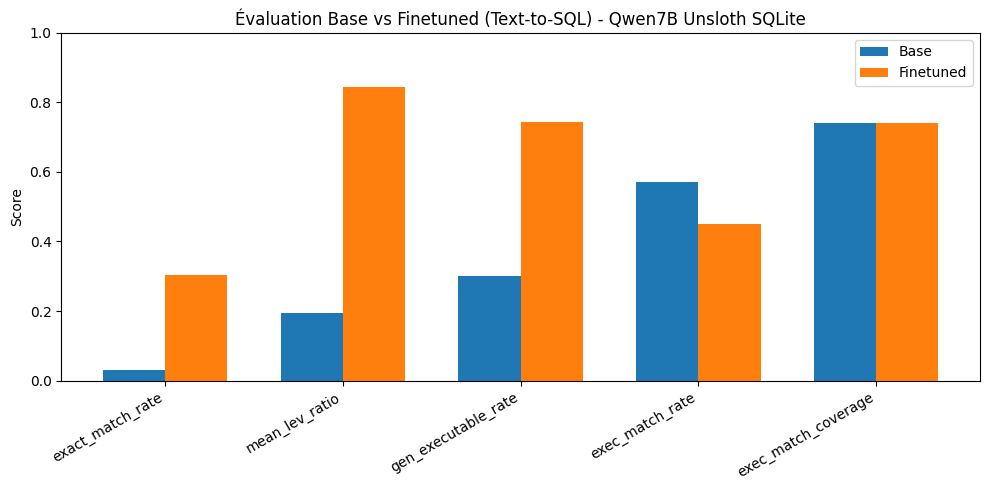

Saved plot to eval_summary_base_vs_finetuned_qwen7b_unsloth.png


In [25]:
# @title Bar chart: Base vs Finetuned

metrics = list(summary_base.keys())
base_vals = [summary_base[m] for m in metrics]
ft_vals   = [summary_ft[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, base_vals, width, label="Base")
plt.bar(x + width/2, ft_vals, width, label="Finetuned")

plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Évaluation Base vs Finetuned (Text-to-SQL) - Qwen7B Unsloth SQLite")
plt.legend()
plt.tight_layout()
plt.savefig("eval_summary_base_vs_finetuned_qwen7b_unsloth.png")
plt.show()

print("Saved plot to eval_summary_base_vs_finetuned_qwen7b_unsloth.png")


In [26]:
!nvidia-smi

Tue Dec 16 18:41:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |   13439MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----